## **Trabajo Practico 2**

### **Descripción del conjunto de datos**

El conjunto de datos `train.csv` contiene **4.200 registros de canciones y 17 variables**, que describen características musicales y permiten explorar sus diferencias entre géneros.

La columna `Expected` indica el género musical de cada registro: *acoustic*, *classical*, *electronic*, *hip-hop*, *jazz* o *rock*. Los seis géneros están balanceados, con **700 observaciones cada uno**.

Las variables se pueden agrupar de la siguiente manera:

- **Información general:** popularidad (`popularity`), duración en milisegundos (`duration_ms`) y presencia de contenido explícito (`explicit`).
- **Características de audio:** bailabilidad (`danceability`), energía (`energy`), sonoridad (`loudness`), presencia de voz hablada (`speechiness`), carácter acústico (`acousticness`), instrumentalidad (`instrumentalness`), presencia de público (`liveness`) y valencia musical (`valence`).
- **Características musicales:** tempo (`tempo`), tonalidad (`key`), modo musical (`mode`) y compás (`time_signature`).
- **Género e identificación:** género musical (`Expected`) e identificador del registro (`Id`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import StratifiedGroupKFold


from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


 Esto hay que analizarlo mas adelante

**No se observan valores faltantes y todos los identificadores son únicos**. Sin embargo, al excluir `Id`, se detectan **663 filas duplicadas** respecto de las demás columnas, cuya naturaleza conviene revisar.

Este conjunto permite analizar la distribución de las características musicales, estudiar las relaciones entre ellas y evaluar qué variables contribuyen a distinguir los géneros.

### **Análisis Exploratorio de Datos**

Al ejecutar `pd.read_csv("train.csv")`, observamos que el dataset contiene **4.200 registros y 17 columnas**, sin valores faltantes a primera vista. La distribucion de tipos en `Dtype` son `int64`, `float64`, `bool` y `object` (que lo entendemos como `string` en nuestro caso) y parecen tener coherencia con la informacion que proporciona la tabla. En el trabajo practico anterior aprendimos que puede haber datos faltantes disfrazados de otro tipo (espacios en blanco como strings), lo cual significa que aunque no haya datos faltantes a primera vista no significa que no los haya. Sin embargo, encontramos que los tipos coinciden correctamente con cada categoria, por ende no tenemos sospechas de que haya datos faltantes. Esta hipotesis luego se confirmara en la etapa de preprocesamiento.

In [2]:
dataset = pd.read_csv("train.csv")
dataset.info()
dataset.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   popularity        4200 non-null   int64  
 1   duration_ms       4200 non-null   int64  
 2   explicit          4200 non-null   bool   
 3   danceability      4200 non-null   float64
 4   energy            4200 non-null   float64
 5   key               4200 non-null   int64  
 6   loudness          4200 non-null   float64
 7   mode              4200 non-null   int64  
 8   speechiness       4200 non-null   float64
 9   acousticness      4200 non-null   float64
 10  instrumentalness  4200 non-null   float64
 11  liveness          4200 non-null   float64
 12  valence           4200 non-null   float64
 13  tempo             4200 non-null   float64
 14  time_signature    4200 non-null   int64  
 15  Expected          4200 non-null   object 
 16  Id                4200 non-null   int64  


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Expected,Id
0,0,143733,False,0.439,0.196,0,-16.093,1,0.0601,0.88000,0.0000,0.0513,0.525,129.581,4,jazz,4271
1,0,261562,False,0.627,0.876,11,-4.391,0,0.0324,0.01590,0.0000,0.0665,0.418,111.950,4,electronic,2078
2,63,190131,False,0.767,0.869,2,-3.381,0,0.0908,0.14000,0.0000,0.2210,0.751,98.208,4,hip-hop,4921
3,48,201440,False,0.374,0.183,9,-13.225,1,0.0281,0.89700,0.0387,0.1090,0.134,82.042,4,acoustic,4206
4,0,168552,True,0.423,0.721,0,-8.070,1,0.1650,0.00792,0.0000,0.3800,0.382,161.926,4,rock,2423


#### Estadisticas Descriptivas
El método `dataset.describe()` proporciona un resumen estadístico de las columnas numéricas: cantidad de valores (`count`), media (`mean`), desviación estándar (`std`), mínimo (`min`), máximo (`max`) y cuartiles (`25%`, `50%` y `75%`). El cuartil `50%` corresponde a la mediana.

En este conjunto de datos, se destacan las siguientes observaciones:

- **Popularidad:** la media es de **28,38** y la mediana de **28**. El primer cuartil es **0**, lo que indica que al menos un 25% de los registros tiene popularidad igual a cero.
- **Duración:** la media es de aproximadamente **3,61 minutos** y la mediana de **3,40 minutos**. El máximo alcanza **44,11 minutos**, un valor que conviene revisar por estar muy alejado de las duraciones habituales.
- **Instrumentalidad:** la mediana es **0** y el tercer cuartil es aproximadamente **0,075**. Esto muestra que la mayoría de los registros presenta valores bajos, aunque algunos alcanzan **0,978**.
- **Carácter acústico:** el 50% central de los valores se encuentra entre **0,075 y 0,853**, lo que refleja una amplia diversidad en esta característica.
- **Tempo:** el promedio es de **117,59 BPM**, pero el mínimo es **0**. Conviene investigar si ese cero representa una medición no disponible.

Estos estadísticos permiten identificar tendencias, dispersión y posibles valores atípicos. Sin embargo, las estadísticas de `Id` no tienen una interpretación musical, y variables como `key`, `mode` y `time_signature` deben interpretarse según sus categorías. Por defecto, `.describe()` no resume las columnas `Expected` y `explicit`.

In [3]:
dataset.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Id
count,4200.000000,4.200000e+03,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.00000
mean,28.379524,2.166272e+05,0.560357,0.505509,5.233571,-10.190675,0.667143,0.068335,0.462576,0.170266,0.175381,0.459639,117.591598,3.874286,2991.09119
std,27.610356,1.090433e+05,0.173039,0.271108,3.589029,6.446329,0.471292,0.071875,0.375937,0.326240,0.136275,0.248920,30.394517,0.481529,1729.94323
min,0.000000,1.745300e+04,0.000000,0.000756,0.000000,-41.531000,0.000000,0.000000,0.000006,0.000000,0.017900,0.000000,0.000000,0.000000,2.00000
25%,0.000000,1.659868e+05,0.443000,0.278000,2.000000,-12.472000,0.000000,0.034100,0.075400,0.000000,0.097500,0.250000,93.931000,4.000000,1490.75000
50%,28.000000,2.038800e+05,0.571000,0.529000,5.000000,-8.187000,1.000000,0.043200,0.417000,0.000052,0.121000,0.445500,116.098000,4.000000,2999.00000
75%,55.000000,2.470400e+05,0.689000,0.737000,8.000000,-5.773250,1.000000,0.065100,0.853000,0.075275,0.209000,0.650000,136.470000,4.000000,4481.25000
max,92.000000,2.646866e+06,0.959000,0.997000,11.000000,-0.927000,1.000000,0.905000,0.996000,0.978000,0.962000,0.980000,214.016000,5.000000,5999.00000


#### Visualizaciones

Para continuar el análisis exploratorio, se crearon visualizaciones con el propósito de comprender qué características pueden estar correlacionadas o presentar diferencias entre los géneros musicales. Primero comenzamos con un gráfico que muestra la proporción de canciones explícitas y no explícitas dentro de cada género. Al representar cada barra como el 100% de las canciones de un género, podemos comparar sus porcentajes aunque todos tengan la misma cantidad de registros.

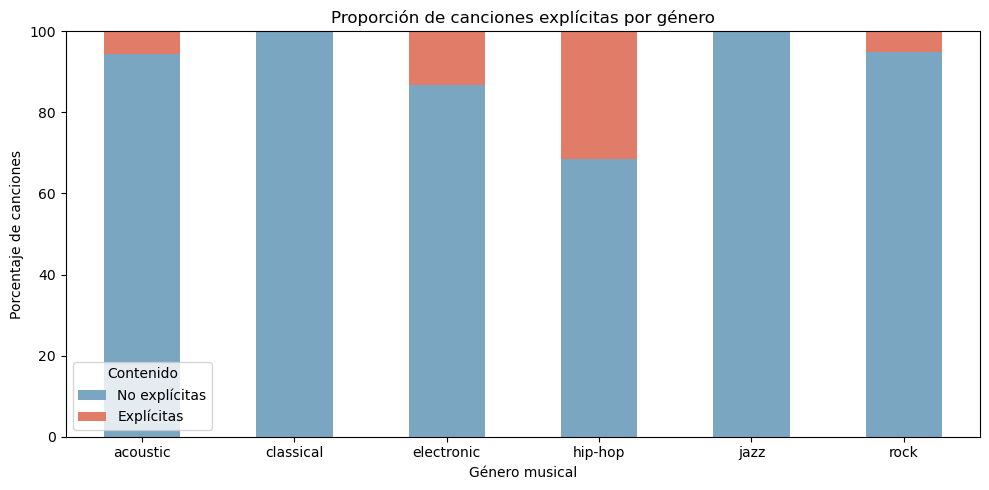

In [4]:
proporciones = pd.crosstab(
    dataset["Expected"],
    dataset["explicit"],
    normalize="index"
).reindex(columns=[False, True], fill_value=0) * 100

proporciones.columns = ["No explícitas", "Explícitas"]

ax = proporciones.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=["#7aa6c2", "#e17c69"]
)

ax.set_title("Proporción de canciones explícitas por género")
ax.set_xlabel("Género musical")
ax.set_ylabel("Porcentaje de canciones")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Contenido")

plt.tight_layout()
plt.show()

El gráfico muestra que la proporción de canciones explícitas varía entre géneros. *Hip-hop* presenta el porcentaje más alto (**31,6%**), seguido por *electronic* (**13,1%**). En *acoustic* (**5,6%**) y *rock* (**5,0%**) la proporción es mucho menor.

En *jazz* solo **2 de 700 canciones** son explícitas (**0,3%**), mientras que en *classical* no hay ninguna. Por lo tanto, dentro de este conjunto de datos, el contenido explícito aparece con mayor frecuencia en *hip-hop* que en los demás géneros.

In [5]:

fig = px.scatter(
    dataset,
    x="acousticness",
    y="energy",
    color="Expected",
    opacity=0.5,
    title="Carácter acústico y energía según el género",
    labels={
        "acousticness": "Acousticness",
        "energy": "Energy",
        "Expected": "Género"
    }
)

fig.update_layout(width=900, height=600)
fig.show()

Este gráfico fue de mucha utilidad para entender cómo se distribuyen los géneros según `acousticness` y `energy`, especialmente al filtrarlos de forma individual. Las observaciones para cada género fueron las siguientes:

**Classical:** Presenta una fuerte concentración en valores altos de `acousticness`, principalmente entre **0,8 y 1**, y valores bajos de `energy`, generalmente entre **0 y 0,4**. Hay unos pocos casos alejados de esta concentración, con baja `acousticness` y alta `energy`.

**Rock:** Se concentra en valores bajos de `acousticness`, especialmente entre **0 y 0,2**, y suele presentar una `energy` elevada. Sin embargo, sus puntos se superponen bastante con los de *electronic* y *hip-hop*.

**Electronic:** También reúne muchas canciones con baja `acousticness` y alta `energy`. Sus valores están más dispersos que los de *rock*, por lo que estas dos variables por sí solas no permiten distinguir ambos géneros con claridad.

**Hip-hop:** La mayoría de sus canciones presenta valores relativamente bajos de `acousticness` y altos de `energy`. En este gráfico comparte gran parte de su área con *rock* y *electronic*.

**Jazz:** Tiende a presentar `acousticness` alta y `energy` baja o moderada. Aunque se acerca a la zona de *classical*, sus valores están más dispersos.

**Acoustic:** Muchas canciones se ubican en valores altos de `acousticness`, pero su `energy` varía considerablemente. Por eso, este género se superpone en parte con *jazz* y *classical*.

En el gráfico anterior, *rock*, *electronic* y *hip-hop* mostraron una considerable superposición al comparar `acousticness` y `energy`. Para explorar otras posibles diferencias, los siguientes gráficos de violín comparan la distribución de `danceability` y `speechiness` en estos tres géneros. Su forma permite observar dónde se concentran los valores y cuánto se superponen las distribuciones.

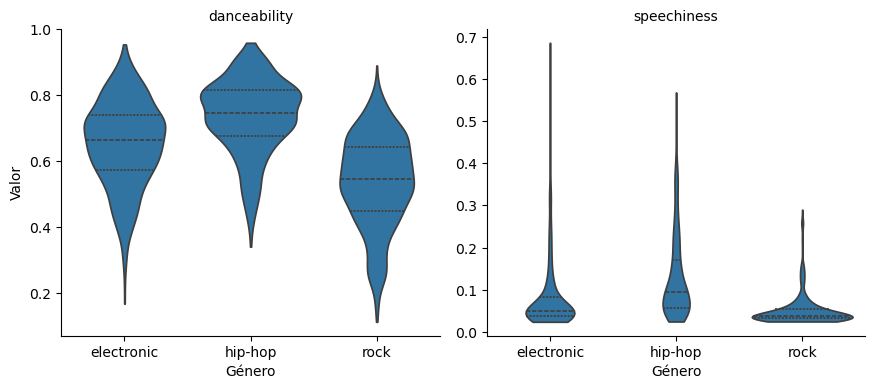

In [6]:
generos = ["rock", "electronic", "hip-hop"]
datos_filtrados = dataset[dataset["Expected"].isin(generos)]

datos_largos = datos_filtrados.melt(
    id_vars="Expected",
    value_vars=["danceability", "speechiness"],
    var_name="Característica",
    value_name="Valor"
)

g = sns.catplot(
    data=datos_largos,
    x="Expected",
    y="Valor",
    col="Característica",
    kind="violin",
    inner="quartile",
    cut=0,
    sharey=False,
    height=4,
    aspect=1.1
)

g.set_axis_labels("Género", "Valor")
g.set_titles("{col_name}")
plt.show()

Este grafico permite encontrar similitudes y diferencias entre sus valores de `danceability` y `speechiness`. En `danceability`, *hip-hop* presenta los valores más altos, seguido por *electronic* y luego *rock*. Sus medianas son aproximadamente **0,75**, **0,66** y **0,55**, respectivamente. 
En `speechiness`, *hip-hop* también tiende a mostrar valores más altos y una mayor dispersión. En cambio, *rock* y *electronic* se concentran en valores bajos y resultan más difíciles de distinguir mediante esta característica. Por lo tanto, estas variables ayudan especialmente a diferenciar *hip-hop*, pero no separan por completo los tres géneros.

Hasta ahora analizamos cómo se distribuyen las características musicales y en qué medida permiten diferenciar los géneros. Para profundizar el análisis y entender las variables con las que tratamos, calculamos las correlaciones entre características dentro de cada género. Estos mapas de calor permiten observar si dos variables tienden a variar juntas y, especialmente, si esa relación cambia de un género a otro. Esto nos interesa porque dos géneros pueden tener valores similares en una característica, pero mostrar patrones distintos al combinarla con otra.

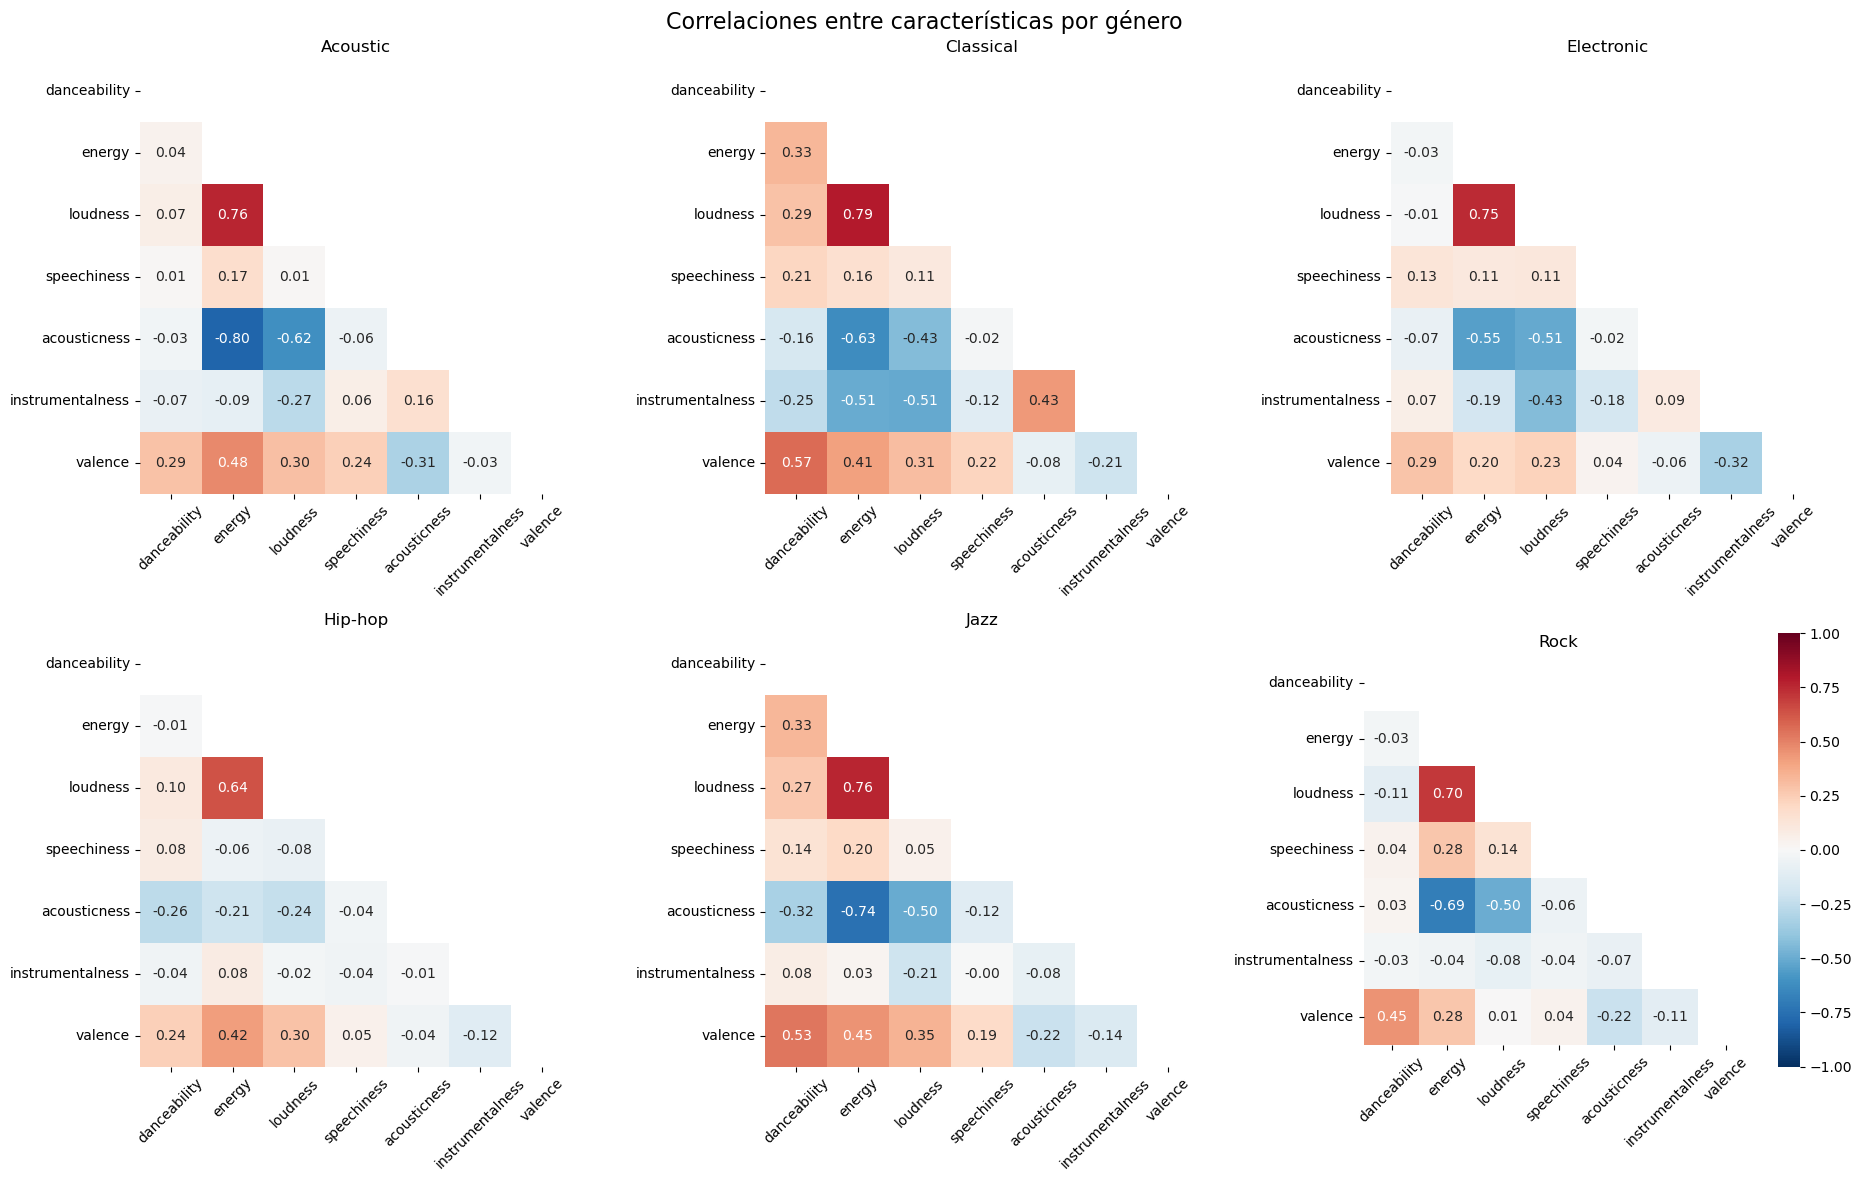

In [7]:
variables = [
    "danceability", "energy", "loudness",
    "speechiness", "acousticness",
    "instrumentalness", "valence"
]

generos = sorted(dataset["Expected"].unique())
fig, axes = plt.subplots(2, 3, figsize=(19, 12))

for i, (ax, genero) in enumerate(zip(axes.flat, generos)):
    datos_genero = dataset[dataset["Expected"] == genero]
    correlaciones = datos_genero[variables].corr()

    # Mostrar solo la mitad inferior para evitar valores repetidos
    mascara = np.triu(np.ones_like(correlaciones, dtype=bool))

    sns.heatmap(
        correlaciones,
        mask=mascara,
        ax=ax,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt=".2f",
        square=True,
        cbar=(i == len(generos) - 1)
    )
    ax.set_title(genero.capitalize())
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Correlaciones entre características por género", fontsize=16)
plt.tight_layout()
plt.show()

Los mapas de correlación muestran que algunas relaciones se repiten en todos los géneros, mientras que otras cambian considerablemente. `energy` y `loudness` presentan una correlación positiva en los seis géneros: las canciones con mayor energía tienden a tener mayor sonoridad.

En cambio, la relación entre `energy` y `acousticness` varía según el género. Es fuertemente negativa en *acoustic* (**−0,80**) y *jazz* (**−0,74**), pero mucho más débil en *hip-hop* (**−0,21**). También observamos que `danceability` y `valence` tienen una correlación positiva más marcada en *classical* (**0,57**) y *jazz* (**0,53**) que en *hip-hop* (**0,24**).

Estos resultados indican que no todas las características se relacionan de la misma manera en cada género. Por eso, analizar únicamente las correlaciones del conjunto completo podría ocultar diferencias relevantes entre ellos.

### Preprocesamiento de los datos

El objetivo del trabajo es predecir el género musical de una canción a partir de sus características. Por eso, separamos el conjunto de datos en las **variables predictoras** (`X`) y la **variable objetivo** (`y`).

La columna `Expected`, que contiene el género musical, se utiliza como variable objetivo. La columna `Id` se excluye de las variables predictoras porque únicamente identifica cada registro y no representa una característica de la canción. Las 15 columnas restantes se conservan como posibles variables predictoras.

In [8]:
X = dataset.drop(columns=["Expected", "Id"])
y = dataset["Expected"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (4200, 15)
Dimensiones de y: (4200,)


##### Revisión de registros repetidos

Durante el preprocesamiento revisamos si existen registros con valores idénticos, sin considerar `Id`, ya que esta columna solo identifica cada fila. Encontramos **663 filas adicionales que repiten tanto las características musicales como el género** de otro registro. Al comparar únicamente las 15 variables predictoras, encontramos **680 filas adicionales con características repetidas**.

La diferencia entre ambos resultados indica que algunas combinaciones idénticas de características tienen géneros asignados distintos. En concreto, encontramos **17 grupos con esta situación, que reúnen 42 registros**. Esto es relevante porque el modelo recibiría los mismos valores de entrada asociados a más de una respuesta correcta.

Los valores repetidos no demuestran necesariamente que se trate de la misma canción, por lo que no los eliminamos automáticamente. Antes de decidir cómo tratarlos, debemos revisar los casos con géneros contradictorios. También debemos evitar que registros con características idénticas queden repartidos entre entrenamiento y evaluación, ya que esto podría producir una estimación demasiado optimista del rendimiento del modelo.

In [9]:
columnas_caracteristicas = X.columns.tolist()

# Mismas características y mismo género (sin considerar Id)
repetidos_completos = dataset.duplicated(
    subset=columnas_caracteristicas + ["Expected"]
).sum()

# Mismas características, aunque el género pueda ser distinto
repetidos_X = dataset.duplicated(
    subset=columnas_caracteristicas
).sum()

# Grupos de características idénticas con más de un género asignado
grupos = dataset.groupby(columnas_caracteristicas, dropna=False)["Expected"].agg(
    cantidad="size",
    generos_distintos="nunique"
)

grupos_con_conflicto = grupos[grupos["generos_distintos"] > 1]

print("Filas repetidas con el mismo género:", repetidos_completos)
print("Filas repetidas considerando solo las características:", repetidos_X)
print("Grupos con géneros diferentes:", len(grupos_con_conflicto))
print("Filas en esos grupos:", grupos_con_conflicto["cantidad"].sum())

Filas repetidas con el mismo género: 663
Filas repetidas considerando solo las características: 680
Grupos con géneros diferentes: 17
Filas en esos grupos: 42


### CAMBIAR DESPUES!! tiene que ser mas detallado, ta muy gpteado
Antes de entrenar el modelo, decidimos eliminar los registros duplicados, sin considerar la columna Id. Aunque conservarlos aumentaría la cantidad de filas, las copias idénticas no aportan información nueva: hacen que ciertas observaciones tengan más peso durante el aprendizaje. Además, si copias de un mismo registro quedaran tanto en el conjunto de entrenamiento como en el de prueba, el modelo podría obtener métricas artificialmente altas al ser evaluado con casos que ya vio. Por este motivo, eliminamos los duplicados exactos para reducir la redundancia y evaluar de forma más confiable su capacidad de predecir el género de canciones nuevas.

In [10]:
filas_antes = len(dataset)

columnas_comparacion = [col for col in dataset.columns if col != "Id"]

dataset = dataset.drop_duplicates(
    subset=columnas_comparacion
).reset_index(drop=True)

# Actualizamos X e y a partir del dataset sin duplicados
X = dataset.drop(columns=["Expected", "Id"])
y = dataset["Expected"]

print("Filas eliminadas:", filas_antes - len(dataset))
print("Filas restantes:", len(dataset))
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Filas eliminadas: 663
Filas restantes: 3537
Dimensiones de X: (3537, 15)
Dimensiones de y: (3537,)


Aunque contamos con un archivo `test.csv`, este no incluye el género real de las canciones y, por lo tanto, no permite evaluar el rendimiento del modelo. Separamos una parte de     para validación, procurando conservar la distribución de géneros y evitando que registros con características idénticas aparezcan tanto en entrenamiento como en validación. Mantendremos `test.csv` para generar las predicciones finales.

In [11]:
# Las filas con características idénticas reciben el mismo grupo
grupos = pd.util.hash_pandas_object(X, index=False)

divisor = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

indices_train, indices_val = next(divisor.split(X, y, groups=grupos))

X_train = X.iloc[indices_train]
X_val = X.iloc[indices_val]
y_train = y.iloc[indices_train]
y_val = y.iloc[indices_val]

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)

Entrenamiento: (2831, 15) (2831,)
Validación: (706, 15) (706,)


Después de eliminar los duplicados exactos, verificamos la calidad de los 3.537 registros restantes. No encontramos valores faltantes ni valores fuera del rango esperado en las características musicales expresadas entre 0 y 1. Detectamos 12 canciones con una duración superior a 15 minutos y 61 con una duración inferior a un minuto. Decidimos conservarlas por el momento, ya que una duración inusual no demuestra que el dato sea erróneo.

También identificamos un registro de jazz con `tempo` y `time_signature` iguales a cero. Como ambos valores corresponden a la misma observación, lo señalamos para revisar su tratamiento durante el modelado, sin eliminar automáticamente la canción.

In [12]:
duracion_min = dataset["duration_ms"] / 60_000

print("Registros:", len(dataset))
print("Valores faltantes:", dataset.isna().sum().sum())
print("Canciones de más de 15 minutos:", (duracion_min > 15).sum())
print("Canciones de menos de 1 minuto:", (duracion_min < 1).sum())
print("Registros con tempo igual a 0:", (dataset["tempo"] == 0).sum())
print("Registros con time_signature igual a 0:",
      (dataset["time_signature"] == 0).sum())

variables_entre_0_y_1 = [
    "danceability", "energy", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence"
]

fuera_de_rango = (
    (dataset[variables_entre_0_y_1] < 0) |
    (dataset[variables_entre_0_y_1] > 1)
)

print("Valores fuera del rango 0–1 por columna:")
print(fuera_de_rango.sum())

Registros: 3537
Valores faltantes: 0
Canciones de más de 15 minutos: 12
Canciones de menos de 1 minuto: 61
Registros con tempo igual a 0: 1
Registros con time_signature igual a 0: 1
Valores fuera del rango 0–1 por columna:
danceability        0
energy              0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
dtype: int64


### Preparación de los tipos de variables

Para preparar los datos antes del entrenamiento, clasificamos las variables predictoras según el tipo de información que representan. `key` y `time_signature` se consideran **categóricas**: aunque sus valores se expresan con números, estos identifican categorías y no deben interpretarse como cantidades. `explicit` y `mode` son **binarias**, ya que solo presentan dos valores posibles.

Las variables restantes, incluida `popularity`, se consideran **numéricas**. Esta distinción nos permitirá aplicar a cada grupo la transformación adecuada. Definimos los grupos en esta etapa, pero ajustaremos las transformaciones únicamente con los datos de entrenamiento para evitar que la validación influya en el modelo.

In [13]:
variables_categoricas = ["key", "time_signature"]
variables_binarias = ["explicit", "mode"]

variables_numericas = [
    columna for columna in X_train.columns
    if columna not in variables_categoricas + variables_binarias
]

print("Categóricas:", variables_categoricas)
print("Binarias:", variables_binarias)
print("Numéricas:", variables_numericas)

Categóricas: ['key', 'time_signature']
Binarias: ['explicit', 'mode']
Numéricas: ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


In [15]:
#Variables binarias
variables_binarias= ['mode', 'explicit']

#Variables categoricas
variables_categoricas = ['key', 'time_signature']

#Variables numericas
variables_numericas = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

#Para las binarias las convertimos en 0's y 1's, para las categoricas implementamos One Hot Encoding y para las numericas el Escalado Estandar
preprocessor = ColumnTransformer(transformers=[('binary',OneHotEncoder(drop='if_binary',handle_unknown='ignore',sparse_output=False),
            variables_binarias),('multicat',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False),
            variables_categoricas),('numeric',StandardScaler(),variables_numericas)],)
